# Using processed CSE-CIC-IDS2018 dataset


This notebook is following the example of [https://www.kaggle.com/code/azazurrehmanbutt/cicids-ids-2018-using-cnn](https://www.kaggle.com/code/azazurrehmanbutt/cicids-ids-2018-using-cnn) to use CNN

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed/csecicids2018"

In [3]:
import os

for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/processed/csecicids2018\Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime


In [5]:
parquet_collection = []

# read parquet files into pandas dataframes
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        if filename.endswith(".parquet"):
            path = os.path.join(dirname, filename)
            print(f"Reading {path}")
            # df = pd.read_parquet(path).sample(frac=0.2, replace=False, random_state=42)
            df = pd.read_parquet(path)
            parquet_collection.append(df)


Reading ../data/processed/csecicids2018\Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet


In [13]:
# read parquet files into pandas dataframes
df = pd.concat(parquet_collection, ignore_index=True)
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [14]:
# get df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6659532 entries, 0 to 6659531
Data columns (total 78 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int64  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  float64
 6   Fwd Packet Length Max     int32  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int32  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              float64
 19  Flow IAT Min              float64
 20  Fwd IAT Total           

In [15]:
# count label values
df['Label'].value_counts()

Label
Benign                      5329008
DDoS attacks-LOIC-HTTP       575364
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          144535
Infilteration                118483
SSH-Bruteforce                94048
DoS attacks-GoldenEye         41406
DoS attacks-Slowloris          9908
DDOS attack-LOIC-UDP           1730
Brute Force -Web                568
Brute Force -XSS                229
SQL Injection                    85
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64

In [16]:
df.isna().sum().to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
# use a label encoder to encode the label column
from sklearn.preprocessing import LabelEncoder

In [18]:
# copy the df
df_copy = df.copy()

# encode the label column and display the unique values 
df_copy['Label'] = LabelEncoder().fit_transform(df['Label'])
df_copy['Label'].unique()

array([ 0,  1, 11, 14,  6,  5,  4,  7, 10,  9,  8, 12,  2,  3, 13])

In [19]:
df_copy['Label'].value_counts()

Label
0     5329008
6      575364
4      198861
8      145199
1      144535
12     118483
14      94048
7       41406
10       9908
5        1730
2         568
3         229
13         85
9          55
11         53
Name: count, dtype: int64

## Use CNN to classify the network traffic data



In [23]:
# make separate datasets for each label

# get the unique values of the label column
labels = df_copy['Label'].unique()

# create a dictionary to store the datasets
label_dfs = {}

# create a dataset for each label
for label in labels:
    label_dfs[label] = df_copy[df_copy['Label'] == label]

# display the first 5 rows of the dataset for each label
for label, label_df in label_dfs.items():
    print(f"Label: {label}")
    print(label_df.head(5))


Label: 0
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6         141385                  9                       7   
1         6            281                  2                       1   
2         6         279824                 11                      15   
3         6            132                  2                       0   
4         6         274016                  9                      13   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                       553                    3773.0                    202   
1                        38                       0.0                     38   
2                      1086                   10527.0                    385   
3                         0                       0.0                      0   
4                      1285                    6141.0                    517   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std

In [25]:
# display the shape of the dataset for each label
for label, label_df in label_dfs.items():
    print(f"Label: {label}")
    print(label_df.shape)
    print()

Label: 0
(5329008, 78)

Label: 1
(144535, 78)

Label: 11
(53, 78)

Label: 14
(94048, 78)

Label: 6
(575364, 78)

Label: 5
(1730, 78)

Label: 4
(198861, 78)

Label: 7
(41406, 78)

Label: 10
(9908, 78)

Label: 9
(55, 78)

Label: 8
(145199, 78)

Label: 12
(118483, 78)

Label: 2
(568, 78)

Label: 3
(229, 78)

Label: 13
(85, 78)



In [28]:
# make feature and label datasets for each label
feature_dfs = {}
label_dfs_encoded = {}

for label, label_df in label_dfs.items():
    feature_dfs[label] = label_df.drop(columns=['Label'])
    label_dfs_encoded[label] = label_df['Label']

# display the first 5 rows for the first label
feature_dfs[0].head(5)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:
# data augmentation
# remove bias from the dataset by resampling all the datasets

from sklearn.utils import resample

# create a dictionary to store the resampled datasets
resampled_feature_dfs = {}
resampled_label_dfs_encoded = {}

# resample each dataset
for label, label_df in label_dfs.items():
    resampled_feature_dfs[label] = resample(feature_dfs[label], replace=True, n_samples=40000, random_state=42)
    resampled_label_dfs_encoded[label] = resample(label_dfs_encoded[label], replace=True, n_samples=40000, random_state=42)

# display the shape of the resampled datasets
for label, label_df in resampled_feature_dfs.items():
    print(f"Label: {label}")
    print(label_df.shape)
    print()


Label: 0
(40000, 77)

Label: 1
(40000, 77)

Label: 11
(40000, 77)

Label: 14
(40000, 77)

Label: 6
(40000, 77)

Label: 5
(40000, 77)

Label: 4
(40000, 77)

Label: 7
(40000, 77)

Label: 10
(40000, 77)

Label: 9
(40000, 77)

Label: 8
(40000, 77)

Label: 12
(40000, 77)

Label: 2
(40000, 77)

Label: 3
(40000, 77)

Label: 13
(40000, 77)



Read about SMOTE later

In [83]:
# combine the resampled datasets
resampled_feature_df = pd.concat(resampled_feature_dfs.values(), ignore_index=True)

resampled_label_df = pd.concat(resampled_label_dfs_encoded.values(), ignore_index=True)

# display the shape of the combined datasets
print(resampled_feature_df.shape)
print(resampled_label_df.shape)


(600000, 77)
(600000,)


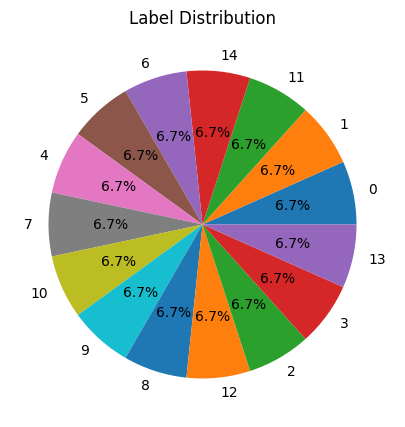

In [84]:
# plot the label distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# plot a circle distribution
plt.pie(resampled_label_df.value_counts(), labels=resampled_label_df.unique(), autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()

In [85]:
# split dataset for cnn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(resampled_feature_df, resampled_label_df, test_size=0.2, random_state=42)

# display the shape of the train and test datasets
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(480000, 77)
(480000,)
(120000, 77)
(120000,)


In [86]:
# convert to categorical
from keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [87]:
X_train.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [88]:
X_train = X_train.drop(columns=['Protocol'])
X_test = X_test.drop(columns=['Protocol'])

In [89]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(480000, 76)
(480000, 15)
(120000, 76)
(120000, 15)


In [90]:
X_train.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
501294,46,2,0,0,0.0,0,0,0.000000,0.000000,0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
285039,2091873,2,0,0,0.0,0,0,0.000000,0.000000,0,...,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47556,9716,3,4,326,129.0,326,0,108.666664,188.216187,112,...,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
580653,52,2,0,0,0.0,0,0,0.000000,0.000000,0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
547794,152,3,0,0,0.0,0,0,0.000000,0.000000,0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
# reshape the data
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

In [93]:
X_train.shape, X_test.shape

((480000, 76, 1), (120000, 76, 1))

In [60]:
# make a CNN model
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv1D(filters=64, kernel_size=6, activation='relu', 
                    padding='same', input_shape=(76, 1)))
model.add(BatchNormalization())

# adding a pooling layer
model.add(MaxPooling1D(pool_size=(3), strides=2, padding='same'))

model.add(Conv1D(filters=64, kernel_size=6, activation='relu', 
                padding='same', input_shape=(76, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=(3), strides=2, padding='same'))

model.add(Conv1D(filters=64, kernel_size=6, activation='relu', 
                padding='same', input_shape=(76, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=(3), strides=2, padding='same'))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(15, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\para_\Desktop\Code\3yp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 76, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 76, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 38, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 19, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,655 (377.56 KB)

 Trainable params: 96,271 (376.06 KB)

 Non-trainable params: 384 (1.50 KB)

In [63]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 76s 5ms/step - accuracy: 0.8532 - loss: 0.2796 - val_accuracy: 0.8499 - val_loss: 0.3084
Epoch 2/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 77s 5ms/step - accuracy: 0.8593 - loss: 0.2625 - val_accuracy: 0.8552 - val_loss: 0.3002
Epoch 3/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 79s 5ms/step - accuracy: 0.8640 - loss: 0.2529 - val_accuracy: 0.6668 - val_loss: 1.1477
Epoch 4/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - accuracy: 0.8647 - loss: 0.2505 - val_accuracy: 0.6156 - val_loss: 1.2521
Epoch 5/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - accuracy: 0.8645 - loss: 0.2522 - val_accuracy: 0.8664 - val_loss: 0.2558
Epoch 6/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - accuracy: 0.8701 - loss: 0.2391 - val_accuracy: 0.8579 - val_loss: 0.2546
Epoch 7/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 81s 5ms/step - accuracy: 0.8731 - loss: 0.2332 - val_accuracy: 0.7740 - val_loss: 0.7835
Epoch 8/30
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 583s 39ms/step - accuracy

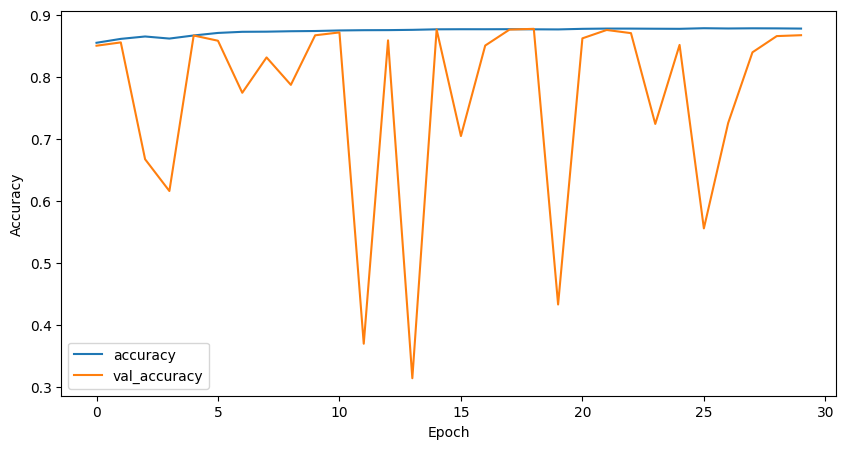

In [94]:
# plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [95]:
# evaluate the model

model.evaluate(X_test, y_test)

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8685 - loss: 0.2656


[0.2691524028778076, 0.8668583035469055]

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


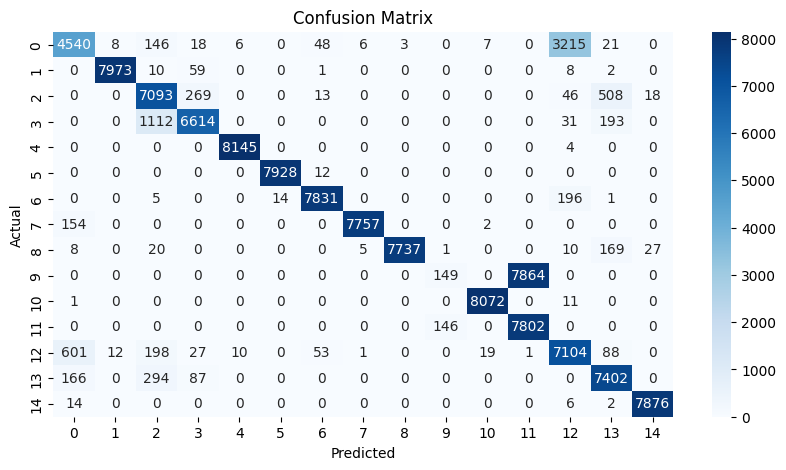

In [97]:
# calculate the confusion matrix and plot it
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_conf = np.argmax(y_test, axis=1)


conf_matrix = confusion_matrix(y_test_conf, y_pred)

import seaborn as sns

plt.figure(figsize=(10, 5))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [99]:
# calculate the classification report
from sklearn.metrics import classification_report

print(classification_report(y_test_conf, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.57      0.67      8018
           1       1.00      0.99      0.99      8053
           2       0.80      0.89      0.84      7947
           3       0.93      0.83      0.88      7950
           4       1.00      1.00      1.00      8149
           5       1.00      1.00      1.00      7940
           6       0.98      0.97      0.98      8047
           7       1.00      0.98      0.99      7913
           8       1.00      0.97      0.98      7977
           9       0.50      0.02      0.04      8013
          10       1.00      1.00      1.00      8084
          11       0.50      0.98      0.66      7948
          12       0.67      0.88      0.76      8114
          13       0.88      0.93      0.91      7949
          14       0.99      1.00      1.00      7898

    accuracy                           0.87    120000
   macro avg       0.87      0.87      0.85    120000
weighted avg       0.87   

In [103]:
# save a lite model for speed and space
model.save('cnn_model.keras')